<a href="https://colab.research.google.com/github/winston-k/Wi20260413/blob/main/py0006h.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning for Function Estimation

#### We'll try to estimate the quality of red wine samples based on their physical and chemical features
#### We compute and report the mean absolute error, MAE

In [1]:
# CNN version
# Regression Example With wine dataset ...
import pandas as pd
from pandas import read_csv
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense , Dropout
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# mounting the Google drive
from google.colab import drive

drive.mount('/content/drive')

# Load the dataset
fp = "/content/drive/My Drive/Emeritus/Wi20260426/Module3-3/wine_r2_t_noheader.csv"




Mounted at /content/drive


In [3]:

# load dataset to a Pandas dataframe
dataframe = read_csv(fp , header=None)
# copy only values to a numpy n dimensional array, ndarray
dataset = dataframe.values

# split into input (X) and output (Y) variables
X = dataset[:,0:11]
Y = dataset[:,11]

print(X.shape)
X = X.reshape(X.shape[0], X.shape[1], 1)
print(X.shape)


(1599, 11)
(1599, 11, 1)


In [4]:
print(type(dataset))
print(dataset.shape)
print(dataframe.describe())
print( dataframe.head() )

<class 'numpy.ndarray'>
(1599, 12)
                0            1            2            3            4   \
count  1599.000000  1599.000000  1599.000000  1599.000000  1599.000000   
mean      8.319637     0.527821     0.270976     2.538806     0.087467   
std       1.741096     0.179060     0.194801     1.409928     0.047065   
min       4.600000     0.120000     0.000000     0.900000     0.012000   
25%       7.100000     0.390000     0.090000     1.900000     0.070000   
50%       7.900000     0.520000     0.260000     2.200000     0.079000   
75%       9.200000     0.640000     0.420000     2.600000     0.090000   
max      15.900000     1.580000     1.000000    15.500000     0.611000   

                5            6            7            8            9   \
count  1599.000000  1599.000000  1599.000000  1599.000000  1599.000000   
mean     15.874922    46.467792     0.996747     3.311113     0.658149   
std      10.460157    32.895324     0.001887     0.154386     0.169507   
mi

In [5]:
# define base model, a deep covolutional one
# structure comprisses 2 1d convolution layers with 16 and 12 filters, filters are 3x1
# then maxpooling for downsampling, a fully connected dense layer with 12 neurons
# Droput layer with 20% at the end
#

# //Winston20260426 eveApple2100h.ipynb ;
"""

def baseline_model():
    # create model
    model = Sequential()
    model.add(Conv1D(16, 3, activation="relu", input_shape=(11,1)))
    model.add(Conv1D(12, 3, activation="relu"))
    model.add(MaxPooling1D())
    model.add(Flatten())
    model.add(Dense(12, input_dim=8, kernel_initializer='normal', activation='relu'))
    model.add( Dropout(0.2) )
    model.add(Dense(1, kernel_initializer='normal'))
    # Compile model
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

"""

"""

def baseline_model():
    # create model
    model = Sequential()
    model.add(Conv1D(16, 3, activation="relu", input_shape=(11,1)))
    model.add(Conv1D(12, 3, activation="relu"))
    model.add(MaxPooling1D())
    model.add(Flatten())
    model.add(Dense(12, kernel_initializer='normal', activation='relu')) # Removed input_dim
    model.add( Dropout(0.2) )
    model.add(Dense(1, kernel_initializer='normal'))
    # Compile model
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

"""



# //Winston20260426 py0006h.ipynb wi gemini solving input dimensions warning by keras ;

def baseline_model():
    # create model
    model = Sequential()
    model.add(Conv1D(16, 3, activation="relu", input_shape=(11,1)))
    model.add(Conv1D(12, 3, activation="relu"))
    model.add(MaxPooling1D())
    model.add(Flatten())
    model.add(Dense(12, kernel_initializer='normal', activation='relu')) # Removed input_dim
    model.add( Dropout(0.2) )
    model.add(Dense(1, kernel_initializer='normal'))
    # Compile model
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

In [6]:
# splitting the train and test subsets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

In [7]:
# training the model for 900 epochs and testing the trained model with the training data
# we report the training error

# //Winston20260426 eveApple2100h.ipynb ;

estimator = baseline_model()
estimator.fit(X_train, Y_train, epochs=420, verbose=2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/420
40/40 - 6s - 147ms/step - loss: 31.2182
Epoch 2/420
40/40 - 0s - 3ms/step - loss: 17.0569
Epoch 3/420
40/40 - 0s - 3ms/step - loss: 11.5622
Epoch 4/420
40/40 - 0s - 3ms/step - loss: 10.6695
Epoch 5/420
40/40 - 0s - 3ms/step - loss: 8.8976
Epoch 6/420
40/40 - 0s - 3ms/step - loss: 6.2723
Epoch 7/420
40/40 - 0s - 3ms/step - loss: 4.8800
Epoch 8/420
40/40 - 0s - 3ms/step - loss: 4.6613
Epoch 9/420
40/40 - 0s - 3ms/step - loss: 4.2880
Epoch 10/420
40/40 - 0s - 3ms/step - loss: 4.5125
Epoch 11/420
40/40 - 0s - 3ms/step - loss: 4.3193
Epoch 12/420
40/40 - 0s - 3ms/step - loss: 4.3727
Epoch 13/420
40/40 - 0s - 3ms/step - loss: 4.6068
Epoch 14/420
40/40 - 0s - 3ms/step - loss: 4.3331
Epoch 15/420
40/40 - 0s - 3ms/step - loss: 4.4575
Epoch 16/420
40/40 - 0s - 3ms/step - loss: 4.2413
Epoch 17/420
40/40 - 0s - 3ms/step - loss: 4.4409
Epoch 18/420
40/40 - 0s - 3ms/step - loss: 3.8895
Epoch 19/420
40/40 - 0s - 3ms/step - loss: 3.9786
Epoch 20/420
40/40 - 0s - 3ms/step - loss: 4.1247
Epo

In [8]:
# //Winston20260426 eveApple2100h.ipynb ;
# splitted this section off so we don't hv to run all the fit epochs again ;

prediction = estimator.predict(X_train)

train_error =  np.abs(Y_train - prediction)
mean_error = np.mean(train_error)
min_error = np.min(train_error)
max_error = np.max(train_error)
std_error = np.std(train_error)
print('\nTraining results:\nmean=',mean_error,'\nmin=',min_error,'\nmax=',max_error,'\nstd=',std_error)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

Training results:
mean= 0.735462718036909 
min= 0.00033855438232421875 
max= 4.021273612976074 
std= 0.525753720707854


In [9]:
# showing the real and predicted quality scores for the training data
df_train1 = pd.DataFrame({'Actual': Y_train, 'Predicted': prediction.ravel() })
df_train25 = df_train1.tail(25)
print(df_train25)

      Actual  Predicted
1254     6.0   5.423900
1255     6.0   5.275720
1256     5.0   5.275720
1257     5.0   5.622785
1258     6.0   5.678504
1259     5.0   5.618704
1260     5.0   5.275720
1261     5.0   5.605243
1262     6.0   5.916135
1263     6.0   6.298814
1264     5.0   5.275720
1265     5.0   5.692049
1266     5.0   5.275720
1267     4.0   5.275720
1268     5.0   5.388345
1269     6.0   5.507119
1270     6.0   5.894777
1271     6.0   6.482347
1272     6.0   5.550299
1273     5.0   5.275720
1274     5.0   5.275720
1275     5.0   5.275720
1276     6.0   5.322738
1277     6.0   5.786094
1278     5.0   5.275720


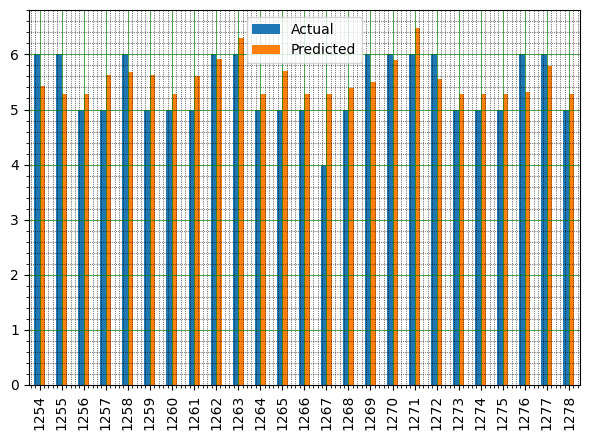

In [10]:
# df1.plot(kind='bar',figsize=(10,8))
# plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
# plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
# plt.show()

# //Winston20260426 eveApple2100h.ipynb ;
# cannot see Colab.Gemini code edits in Chrome on Apple ;
df_train25.plot(kind='bar',figsize=(6,4.5))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.minorticks_on()
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
# //Winston20260426 eveApple2100h.ipynb ;
plt.tight_layout()
plt.show()

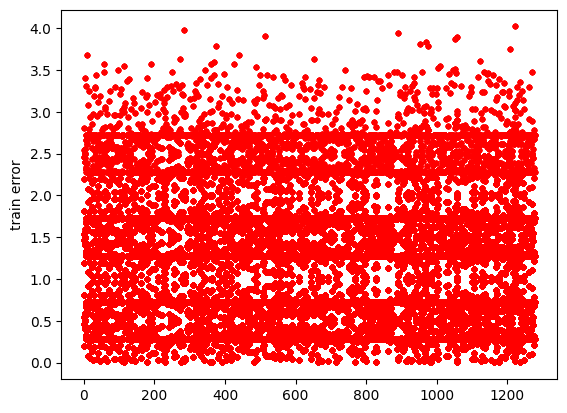

In [11]:
plt.plot(train_error,'r.')
plt.ylabel('train error')
plt.show()

In [12]:
# testing the model with the test data
prediction = estimator.predict(X_test)

test_error =  np.abs(Y_test - prediction)
mean_error = np.mean(test_error)
min_error = np.min(test_error)
max_error = np.max(test_error)
std_error = np.std(test_error)
print('\nTesting results:\nmean=',mean_error,'\nmin=',min_error,'\nmax=',max_error,'\nstd=',std_error)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Testing results:
mean= 0.6863526630401612 
min= 2.86102294921875e-06 
max= 3.9832096099853516 
std= 0.49790212552250485


In [13]:
# and showing the results
df_test1 = pd.DataFrame({'Actual': Y_test, 'Predicted': prediction.ravel() })
df_test25 = df_test1.tail(25)
print(df_test25)

     Actual  Predicted
295     6.0   5.727218
296     6.0   5.520314
297     5.0   5.648234
298     6.0   5.275720
299     5.0   5.275720
300     6.0   5.494576
301     5.0   5.275720
302     6.0   5.542541
303     6.0   5.858410
304     6.0   5.873368
305     6.0   5.656260
306     5.0   5.275720
307     5.0   5.275720
308     6.0   5.726296
309     5.0   5.538679
310     5.0   5.716629
311     6.0   6.048903
312     5.0   5.729024
313     5.0   5.275720
314     5.0   5.275720
315     6.0   5.663683
316     4.0   5.944163
317     5.0   5.884384
318     4.0   5.275720
319     6.0   5.842120


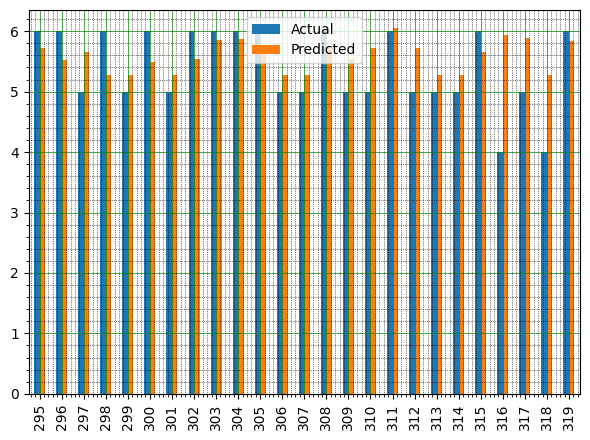

In [14]:
# df1.plot(kind='bar',figsize=(10,8))
# plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
# plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
# plt.show()

# //Winston20260426 eveApple2100h.ipynb ;
# cannot see Colab.Gemini code edits in Chrome on Apple ;
df_test25.plot(kind='bar',figsize=(6,4.5))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.minorticks_on()
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
# //Winston20260426 eveApple2100h.ipynb ;
plt.tight_layout()
plt.show()

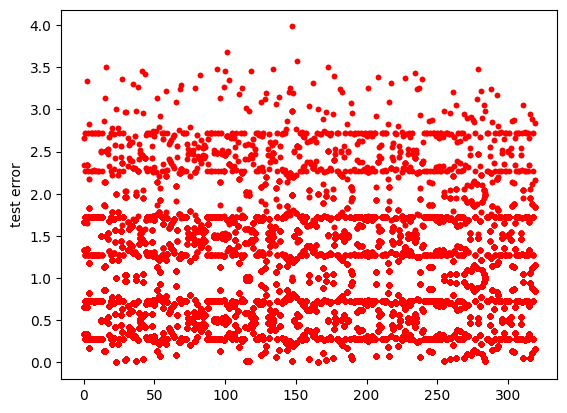

In [15]:
plt.plot(test_error,'r.')
plt.ylabel('test error')
plt.show()

##  Practices
1. train the model for 1400 epochs. what are the training and testing MAE?
2. repeat that with 6000 training epochs. what are the training and testing MAE?
3. move back to 900 training epochs. add two convolutional and one dense layer with the same features of the layers used. what are the training and testing MAE?
4. go for 6000 training epochs. Do you feel any overfitting?
5. set back everything to the original setting, then try to normalize the training and testing features and outputs using standard_scaler. Then see if anything gets better or not. You may use insttructions like what you can see in the next cell.  

#### points:
- use GPU as your runtime type
- if the notebook overflows, change the verbose to 0, e.g. verbose=0 in the training cell.

In [16]:
'''
# normalization
from sklearn.preprocessing import StandardScaler

# Create scalers
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Standardize X_train and X_test
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Standardize Y_train and Y_test (only if y is continuous, e.g., in regression)
y_train_scaled = scaler_y.fit_transform(Y_train.reshape(-1, 1))  # Reshape if needed
y_test_scaled = scaler_y.transform(Y_test.reshape(-1, 1))
'''

'\n# normalization\nfrom sklearn.preprocessing import StandardScaler\n\n# Create scalers\nscaler_X = StandardScaler()\nscaler_y = StandardScaler()\n\n# Standardize X_train and X_test\nX_train_scaled = scaler_X.fit_transform(X_train)\nX_test_scaled = scaler_X.transform(X_test)\n\n# Standardize Y_train and Y_test (only if y is continuous, e.g., in regression)\ny_train_scaled = scaler_y.fit_transform(Y_train.reshape(-1, 1))  # Reshape if needed\ny_test_scaled = scaler_y.transform(Y_test.reshape(-1, 1))\n'